# Customer Churn Prediction — Reusable ML Pipeline


**Dataset**: 36,992 customers | **Target**: `churn_risk_score` (0 = No Churn, 1 = Churn)

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print('Libraries loaded successfully.')

Libraries loaded successfully.


## Load and Inspect Dataset

In [2]:
df = pd.read_csv('churn.csv')
df.head(3)

,Unnamed: 0,age,gender,security_no,region_category,membership_category,joining_date,joined_through_referral,referral_id,preferred_offer_types,...,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback,churn_risk_score
0,0,18,F,XW0DQ7H,Village,Platinum Membership,2017-08-17,No,xxxxxxxx,Gift Vouchers/Coupons,...,300.63,53005.25,17.0,781.75,Yes,Yes,No,Not Applicable,Products always in Stock,0
1,1,32,F,5K0N3X1,City,Premium Membership,2017-08-28,?,CID21329,Gift Vouchers/Coupons,...,306.34,12838.38,10.0,NaN,Yes,No,Yes,Solved,Quality Customer Care,0
2,2,44,F,1F2TCL3,Town,No Membership,2016-11-11,Yes,CID12313,Gift Vouchers/Coupons,...,516.16,21027.00,22.0,500.69,No,Yes,Yes,Solved in Follow-up,Poor Website,1


In [3]:
print(f'Shape: {df.shape}')

Shape: (36992, 24)


In [4]:
df.columns

Index(['Unnamed: 0', 'age', 'gender', 'security_no', 'region_category',
       'membership_category', 'joining_date', 'joined_through_referral',
       'referral_id', 'preferred_offer_types', 'medium_of_operation',
       'internet_option', 'last_visit_time', 'days_since_last_login',
       'avg_time_spent', 'avg_transaction_value', 'avg_frequency_login_days',
       'points_in_wallet', 'used_special_discount',
       'offer_application_preference', 'past_complaint', 'complaint_status',
       'feedback', 'churn_risk_score'],
      dtype='str')

In [5]:
df.rename(columns={"churn_risk_score":"churn"},inplace=True)

#### Missing values:

In [6]:
print(df.isnull().sum()[df.isnull().sum() > 0])

region_category          5428
preferred_offer_types     288
points_in_wallet         3443
dtype: int64


In [7]:
print(f'\nTarget distribution:')
print(df['churn'].value_counts())


Target distribution:
churn
1    20012
0    16980
Name: count, dtype: int64


## Drop Unnecessary Columns

In [8]:
drop_cols = ['Unnamed: 0', 'security_no', 'referral_id',
             'joining_date', 'last_visit_time', 'feedback']
df = df.drop(columns=drop_cols)


In [9]:
print(f'Remaining columns ({len(df.columns)}):\n {list(df.columns)}')

Remaining columns (18):
 ['age', 'gender', 'region_category', 'membership_category', 'joined_through_referral', 'preferred_offer_types', 'medium_of_operation', 'internet_option', 'days_since_last_login', 'avg_time_spent', 'avg_transaction_value', 'avg_frequency_login_days', 'points_in_wallet', 'used_special_discount', 'offer_application_preference', 'past_complaint', 'complaint_status', 'churn']


## Fix Data Type Issues

In [10]:
for col in df.select_dtypes(include=["str"]).columns:
    print("*"*60)
    print(df[col].value_counts())

************************************************************
gender
F          18490
M          18443
Unknown       59
Name: count, dtype: int64
************************************************************
region_category
Town       14128
City       12737
Village     4699
Name: count, dtype: int64
************************************************************
membership_category
Basic Membership       7724
No Membership          7692
Gold Membership        6795
Silver Membership      5988
Premium Membership     4455
Platinum Membership    4338
Name: count, dtype: int64
************************************************************
joined_through_referral
No     15839
Yes    15715
?       5438
Name: count, dtype: int64
************************************************************
preferred_offer_types
Gift Vouchers/Coupons       12349
Credit/Debit Card Offers    12274
Without Offers              12081
Name: count, dtype: int64
************************************************************
medi

In [11]:
# avg_frequency_login_days was read as strings — convert to numeric
df['avg_frequency_login_days'] = pd.to_numeric(df['avg_frequency_login_days'], errors='coerce')

# '?' is a sentinel for unknown — treat as NaN so the pipeline imputer fills it
df['joined_through_referral'] = df['joined_through_referral'].replace('?', np.nan)
df['medium_of_operation']     = df['medium_of_operation'].replace('?', np.nan)
df['gender'] = df['gender'].replace('Unknown', np.nan)
df['complaint_status'] = df['complaint_status'].replace('No Information Available', np.nan)

print('After fixes datatypes:')
print(df[['avg_frequency_login_days', 'joined_through_referral', 'medium_of_operation','gender','complaint_status']].dtypes)
print("\n\n")

print('After fixes null count:')
print(df[['avg_frequency_login_days', 'joined_through_referral', 'medium_of_operation','gender','complaint_status']].isnull().sum())

After fixes datatypes:
avg_frequency_login_days    float64
joined_through_referral         str
medium_of_operation             str
gender                          str
complaint_status                str
dtype: object



After fixes null count:
avg_frequency_login_days    3522
joined_through_referral     5438
medium_of_operation         5393
gender                        59
complaint_status            4550
dtype: int64


## Separate Features and Target

In [12]:
X = df.drop('churn', axis=1)
y = df['churn']

print(f'Features shape: {X.shape} | Churn rate: {y.mean():.1%}')

Features shape: (36992, 17) | Churn rate: 54.1%


## Train-Test Split (80:20)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')
print(f'Train churn rate: {y_train.mean():.1%} | Test churn rate: {y_test.mean():.1%}')

Train: 29,593 | Test: 7,399
Train churn rate: 54.1% | Test churn rate: 54.1%


## Define Feature Groups.

In [14]:
numeric_features = [
    'age', 'days_since_last_login', 'avg_time_spent',
    'avg_transaction_value', 'avg_frequency_login_days', 'points_in_wallet'
]

categorical_features = [
    'gender', 'region_category', 'membership_category',
    'joined_through_referral',
    'preferred_offer_types', 'medium_of_operation', 'internet_option',
    'used_special_discount', 'offer_application_preference',
    'past_complaint', 'complaint_status'
]

print(f'Numeric  ({len(numeric_features)}): {numeric_features}')
print("\n")
print(f'Categorical ({len(categorical_features)}): {categorical_features}')

Numeric  (6): ['age', 'days_since_last_login', 'avg_time_spent', 'avg_transaction_value', 'avg_frequency_login_days', 'points_in_wallet']


Categorical (11): ['gender', 'region_category', 'membership_category', 'joined_through_referral', 'preferred_offer_types', 'medium_of_operation', 'internet_option', 'used_special_discount', 'offer_application_preference', 'past_complaint', 'complaint_status']


## Preprocessing Pipelines

In [15]:
# Numerical: fill NaN with median, then scale
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# Categorical: fill NaN with most frequent, then one-hot encode
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine with ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline,     numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

print('Preprocessing pipelines created.')

Preprocessing pipelines created.


## Full Reusable ML Pipeline

In [16]:
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

In [17]:
model_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

## Train the Pipeline

In [18]:
print('Training pipeline on training data...')
model_pipeline.fit(X_train, y_train)
print('Training complete!')

Training pipeline on training data...
Training complete!


## Predict on Test Data

In [19]:
y_pred = model_pipeline.predict(X_test)
print(f'Sample predictions: {y_pred[:10]}')

Sample predictions: [0 1 0 1 0 1 0 0 1 1]


## Evaluate the Model

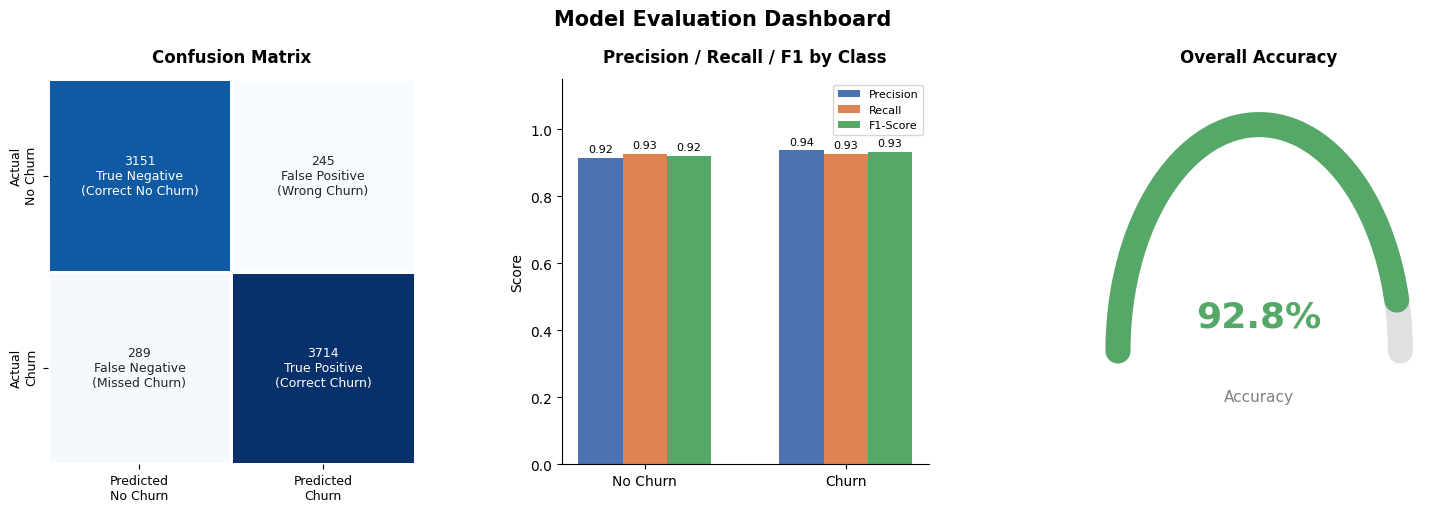

In [20]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import classification_report
import numpy as np

# ── Data prep ──────────────────────────────────────────────────
acc    = accuracy_score(y_test, y_pred)
cm     = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred,
                               target_names=['No Churn', 'Churn'],
                               output_dict=True)

# ── Layout: 1 row, 3 panels ────────────────────────────────────
fig = plt.figure(figsize=(18, 5))
fig.suptitle('Model Evaluation Dashboard', fontsize=15, fontweight='bold', y=1.02)
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.4)

# ── Panel 1: Confusion Matrix ──────────────────────────────────
ax1 = fig.add_subplot(gs[0])
labels = [['True Negative\n(Correct No Churn)', 'False Positive\n(Wrong Churn)'],
          ['False Negative\n(Missed Churn)',     'True Positive\n(Correct Churn)']]
annot  = [[f'{cm[i,j]}\n{labels[i][j]}' for j in range(2)] for i in range(2)]
sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', ax=ax1,
            xticklabels=['Predicted\nNo Churn', 'Predicted\nChurn'],
            yticklabels=['Actual\nNo Churn',    'Actual\nChurn'],
            linewidths=1, linecolor='white', cbar=False,
            annot_kws={'size': 9})
ax1.set_title('Confusion Matrix', fontweight='bold', pad=12)
ax1.tick_params(labelsize=9)

# ── Panel 2: Per-class Precision / Recall / F1 ────────────────
ax2     = fig.add_subplot(gs[1])
classes = ['No Churn', 'Churn']
metrics = ['precision', 'recall', 'f1-score']
metric_labels = ['Precision', 'Recall', 'F1-Score']
x      = np.arange(len(classes))
width  = 0.22
colors = ['#4C72B0', '#DD8452', '#55A868']

for i, (m, lbl, col) in enumerate(zip(metrics, metric_labels, colors)):
    vals = [report[c][m] for c in classes]
    bars = ax2.bar(x + i*width, vals, width, label=lbl, color=col)
    for bar, v in zip(bars, vals):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{v:.2f}', ha='center', va='bottom', fontsize=8)

ax2.set_xticks(x + width)
ax2.set_xticklabels(classes, fontsize=10)
ax2.set_ylim(0, 1.15)
ax2.set_ylabel('Score')
ax2.set_title('Precision / Recall / F1 by Class', fontweight='bold', pad=12)
ax2.legend(fontsize=8)
ax2.spines[['top', 'right']].set_visible(False)

# ── Panel 3: Accuracy gauge ────────────────────────────────────
ax3 = fig.add_subplot(gs[2])
theta = np.linspace(np.pi, 0, 300)
ax3.plot(np.cos(theta), np.sin(theta), color='#e0e0e0', lw=18, solid_capstyle='round')
fill_theta = np.linspace(np.pi, np.pi - acc * np.pi, 300)
color = '#55A868' if acc >= 0.80 else '#DD8452' if acc >= 0.65 else '#C44E52'
ax3.plot(np.cos(fill_theta), np.sin(fill_theta), color=color, lw=18, solid_capstyle='round')
ax3.text(0,  0.15, f'{acc:.1%}', ha='center', va='center', fontsize=26, fontweight='bold', color=color)
ax3.text(0, -0.2,  'Accuracy',   ha='center', va='center', fontsize=11, color='gray')
ax3.set_xlim(-1.3, 1.3)
ax3.set_ylim(-0.5, 1.2)
ax3.axis('off')
ax3.set_title('Overall Accuracy', fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## Feature Importance (Top 15)

In [21]:
ohe_features = (model_pipeline
    .named_steps['preprocessor']
    .named_transformers_['cat']['encoder']
    .get_feature_names_out(categorical_features)
    .tolist()
)
all_feature_names = numeric_features + ohe_features
importances = model_pipeline.named_steps['model'].feature_importances_

feat_df = (pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
           .sort_values('Importance', ascending=False)
           .head(15)
           .reset_index(drop=True))

print('Top 15 Features Driving Churn:')
print(feat_df.to_string(index=False))

Top 15 Features Driving Churn:
                                Feature  Importance
                       points_in_wallet    0.329361
   membership_category_Basic Membership    0.121210
      membership_category_No Membership    0.121039
 membership_category_Premium Membership    0.081075
membership_category_Platinum Membership    0.075880
                  avg_transaction_value    0.056873
               avg_frequency_login_days    0.028850
                         avg_time_spent    0.028588
                                    age    0.024026
                  days_since_last_login    0.021167
    membership_category_Gold Membership    0.018730
  membership_category_Silver Membership    0.014911
                   region_category_Town    0.003882
                   region_category_City    0.003766
            internet_option_Mobile_Data    0.003740


## Saving the Reusable Pipeline

In [22]:
joblib.dump(model_pipeline, 'customer_churn_pipeline.pkl')
print('Pipeline saved to customer_churn_pipeline.pkl')

Pipeline saved to customer_churn_pipeline.pkl


## Load and Predict for a New Customer

In [23]:
loaded_pipeline = joblib.load('customer_churn_pipeline.pkl')

new_customer = pd.DataFrame([{
    'age': 35,
    'gender': 'M',
    'region_category': 'City',
    'membership_category': 'Basic Membership',
    'joined_through_referral': 'Yes',
    'preferred_offer_types': 'Gift Vouchers/Coupons',
    'medium_of_operation': 'Desktop',
    'internet_option': 'Wi-Fi',
    'days_since_last_login': 20,
    'avg_time_spent': 25.0,
    'avg_transaction_value': 30000.0,
    'avg_frequency_login_days': 15.0,
    'points_in_wallet': 600.0,
    'used_special_discount': 'Yes',
    'offer_application_preference': 'No',
    'past_complaint': 'Yes',
    'complaint_status': 'Unsolved',
}])

pred = loaded_pipeline.predict(new_customer)[0]
prob = loaded_pipeline.predict_proba(new_customer)[0][1]

print(f"Churn Prediction: {'CHURN' if pred == 1 else 'NO CHURN'}")
print(f'Churn Probability: {prob:.1%}')

Churn Prediction: CHURN
Churn Probability: 96.0%
